In [1]:
import xgboost
print("xgboost:", xgboost.__version__)

xgboost: 3.2.0


## 1. Setup and the shared evaluation harness
Load the data, rebuild X/y with the same 32 features and the same dropped columns as Notebook 2, and fix one 5-fold split every model shares. Two helpers do the repetitive work: one cross-validates a tuned model and prints its full report + confusion matrix, the other draws its feature importance. Labels are encoded to integers in our class order — XGBoost needs that, and it keeps every confusion matrix in the same order.

In [2]:
# Notebook 3 — classifier comparison (pick the deployed winner)
import pandas as pd, numpy as np, sklearn, json, joblib
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import (StratifiedKFold, GridSearchCV,
                                     cross_val_predict, cross_val_score)
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", None)
print("sklearn:", sklearn.__version__)

# --- config (identical to Notebooks 1 & 2) ---
FEATURES_DIR = r"C:\tpot-project\04-features"
BEHAV_PATH   = FEATURES_DIR + r"\dataset_behavioral.csv"
MODELS_DIR   = r"C:\tpot-project\06-models"
ID_COL, LABEL_COL = "run_id", "label"
CLASS_ORDER  = ["scan", "online_guessing", "post_exploitation", "web_attack", "denial_of_service"]
RANDOM_STATE = 42

# --- load + build X, y (SAME drop-by-name logic as Notebook 2 -> 32 features) ---
df_behav = pd.read_csv(BEHAV_PATH)
DROP_COLS = ["n_file_downloads", "any_file_download"]
model_features = [c for c in df_behav.columns if c not in [ID_COL, LABEL_COL, *DROP_COLS]]
X = df_behav[model_features].values
y = df_behav[LABEL_COL].values                          # text labels
run_ids = df_behav[ID_COL].values

# integer labels in OUR class order (XGBoost needs ints; fixes confusion-matrix order)
class_to_id = {c: i for i, c in enumerate(CLASS_ORDER)}
y_enc = np.array([class_to_id[c] for c in y])
LABEL_IDS = list(range(len(CLASS_ORDER)))
print("X:", X.shape, "| features:", len(model_features), "(expect 32)")

# --- one shared 5-fold split for EVERY model = fair comparison ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []   # each model appends one summary row

def top_combos(grid, n=10):
    res = pd.DataFrame(grid.cv_results_)
    pcols = [c for c in res.columns if c.startswith("param_")]
    out = (res[["mean_test_score", "std_test_score"] + pcols]
           .sort_values(["mean_test_score", "std_test_score"], ascending=[False, True])
           .head(n).reset_index(drop=True))
    out.index = out.index + 1
    return out.round(4)

def full_evaluate(name, estimator, scaled):
    """Cross-validate a tuned model over all 150 runs: metrics + per-class report + confusion
       matrix + misclassified runs, and append one summary row to `results`. Integer labels
       throughout, so every model (including XGBoost) runs identical code."""
    pred = cross_val_predict(estimator, X, y_enc, cv=cv)
    acc  = cross_val_score(estimator, X, y_enc, cv=cv, scoring="accuracy")
    f1   = cross_val_score(estimator, X, y_enc, cv=cv, scoring="f1_macro")
    n_err = int((pred != y_enc).sum())

    print(f"=== {name} — cross-validated over all 150 runs ===")
    print(f"accuracy : {acc.mean():.4f} ± {acc.std():.4f}")
    print(f"macro-F1 : {f1.mean():.4f} ± {f1.std():.4f}")
    print(f"errors   : {n_err}/{len(y_enc)}\n")
    print(classification_report(y_enc, pred, labels=LABEL_IDS,
                                target_names=CLASS_ORDER, digits=3))

    cm = confusion_matrix(y_enc, pred, labels=LABEL_IDS)
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(cm, display_labels=CLASS_ORDER).plot(
        ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
    ax.set_title(f"{name} — cross-validated (acc {acc.mean():.3f})"); ax.grid(False)
    plt.tight_layout(); plt.show()

    mask = pred != y_enc
    if mask.any():
        print("misclassified runs:")
        for rid, t, p in sorted(zip(run_ids[mask], y_enc[mask], pred[mask])):
            print(f"   {rid}: true={CLASS_ORDER[t]:18} -> pred={CLASS_ORDER[p]}")
    else:
        print("no misclassified runs.")

    results.append({"model": name, "scaled": scaled,
                    "cv_accuracy": round(acc.mean(), 4), "acc_std": round(acc.std(), 4),
                    "cv_macro_f1": round(f1.mean(), 4), "errors": n_err})
    return pred

def show_importance(name, fitted_model, n=15):
    """Built-in + permutation importance for tree/boosting models (fitted on all 150 rows)."""
    gini = pd.Series(fitted_model.feature_importances_, index=model_features).sort_values(ascending=False)
    perm = permutation_importance(fitted_model, X, y_enc, n_repeats=20,
                                  random_state=RANDOM_STATE, n_jobs=-1)
    perm = pd.Series(perm.importances_mean, index=model_features).sort_values(ascending=False)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
    gini.head(n).iloc[::-1].plot.barh(ax=axes[0], color="steelblue")
    axes[0].set_title(f"{name} — built-in importance"); axes[0].set_xlabel("importance")
    perm.head(n).iloc[::-1].plot.barh(ax=axes[1], color="darkorange")
    axes[1].set_title(f"{name} — permutation importance"); axes[1].set_xlabel("accuracy drop when shuffled")
    plt.tight_layout(); plt.show()

sklearn: 1.9.0
X: (150, 32) | features: 32 (expect 32)


## 2. Anchor — the Random Forest from Notebook 2
Re-score the tuned Random Forest here under the identical harness, so its numbers come from the same code as every other model instead of being copied over from Notebook 2. This is the baseline the rest must beat — it should reproduce Notebook 2 exactly: 0.980 accuracy and the three W-run web→DoS errors.

=== Random Forest — cross-validated over all 150 runs ===
accuracy : 0.9800 ± 0.0163
macro-F1 : 0.9799 ± 0.0164
errors   : 3/150

                   precision    recall  f1-score   support

             scan      1.000     1.000     1.000        30
  online_guessing      1.000     1.000     1.000        30
post_exploitation      1.000     1.000     1.000        30
       web_attack      1.000     0.900     0.947        30
denial_of_service      0.909     1.000     0.952        30

         accuracy                          0.980       150
        macro avg      0.982     0.980     0.980       150
     weighted avg      0.982     0.980     0.980       150



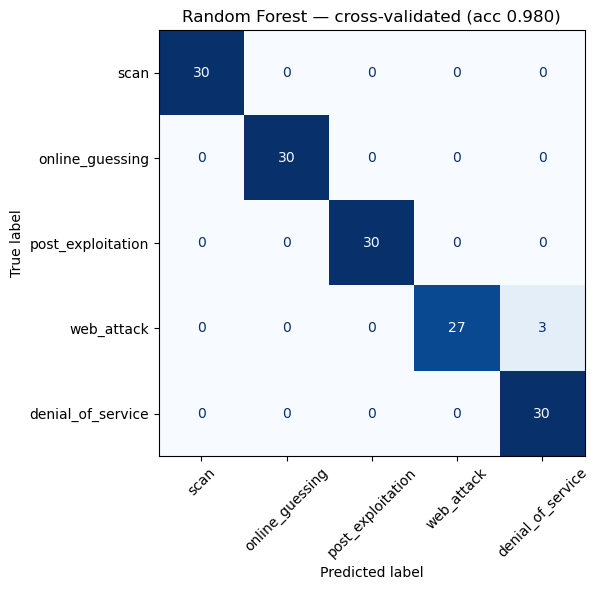

misclassified runs:
   W001: true=web_attack         -> pred=denial_of_service
   W002: true=web_attack         -> pred=denial_of_service
   W003: true=web_attack         -> pred=denial_of_service


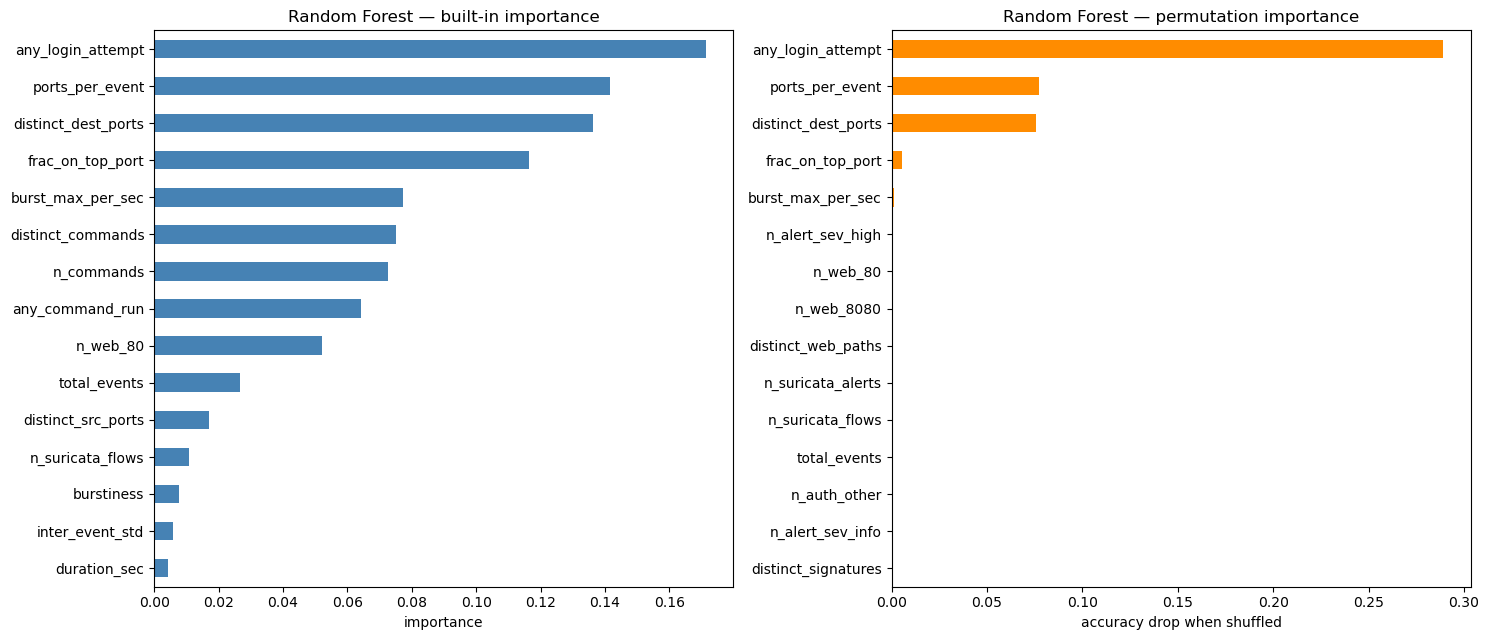

In [3]:
rf_params = dict(criterion="gini", max_depth=None, max_features=None,
                 min_samples_leaf=1, min_samples_split=2, n_estimators=300)
rf = RandomForestClassifier(**rf_params, random_state=RANDOM_STATE, n_jobs=-1)
pred_rf = full_evaluate("Random Forest", rf, scaled=False)
show_importance("Random Forest", rf.fit(X, y_enc))   # fit on all 150 for importance

## 3. XGBoost — regularized gradient boosting
Like Gradient Boosting, XGBoost adds shallow trees in sequence, each correcting the previous trees' mistakes — but with built-in regularization and a faster, smarter build, which is why it wins most tabular-data competitions. Still a tree model, so no scaling. The grid pairs the boosting essentials (learning rate × number of trees × depth) with XGBoost's own row and column subsampling and a leaf-size guard.

In [4]:
from xgboost import XGBClassifier

XGB_GRID = {
    "n_estimators":     [200, 400, 600],
    "learning_rate":    [0.03, 0.1, 0.3],
    "max_depth":        [3, 4, 6],
    "subsample":        [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3],
}
n = int(np.prod([len(v) for v in XGB_GRID.values()]))
print(f"grid size: {n} settings x 5 folds = {n*5} fits\n")

# let XGBClassifier infer objective + num_class from the labels (don't set them manually)
xgb_base = XGBClassifier(eval_metric="mlogloss", tree_method="hist",
                         random_state=RANDOM_STATE, n_jobs=1)
grid_xgb = GridSearchCV(xgb_base, XGB_GRID, cv=cv, scoring="accuracy", n_jobs=-1).fit(X, y_enc)
print("best CV accuracy:", round(grid_xgb.best_score_, 4))
print("best params     :", grid_xgb.best_params_)
top_combos(grid_xgb, 10)

grid size: 216 settings x 5 folds = 1080 fits

best CV accuracy: 0.9867
best params     : {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 400, 'subsample': 1.0}


,mean_test_score,std_test_score,param_colsample_bytree,param_learning_rate,param_max_depth,param_min_child_weight,param_n_estimators,param_subsample
1,0.9867,0.0163,0.8,0.03,3,1,400,1.0
2,0.9867,0.0163,0.8,0.03,4,1,400,1.0
3,0.9867,0.0163,0.8,0.03,6,1,400,1.0
4,0.9800,0.0163,0.8,0.03,3,1,400,0.8
5,0.9800,0.0163,0.8,0.03,3,1,600,0.8
6,0.9800,0.0163,0.8,0.03,3,1,600,1.0
7,0.9800,0.0163,0.8,0.03,3,3,200,1.0
8,0.9800,0.0163,0.8,0.03,3,3,400,1.0
9,0.9800,0.0163,0.8,0.03,3,3,600,1.0
10,0.9800,0.0163,0.8,0.03,4,1,400,0.8


=== XGBoost — cross-validated over all 150 runs ===
accuracy : 0.9867 ± 0.0163
macro-F1 : 0.9866 ± 0.0164
errors   : 2/150

                   precision    recall  f1-score   support

             scan      1.000     1.000     1.000        30
  online_guessing      1.000     1.000     1.000        30
post_exploitation      1.000     1.000     1.000        30
       web_attack      1.000     0.933     0.966        30
denial_of_service      0.938     1.000     0.968        30

         accuracy                          0.987       150
        macro avg      0.988     0.987     0.987       150
     weighted avg      0.988     0.987     0.987       150



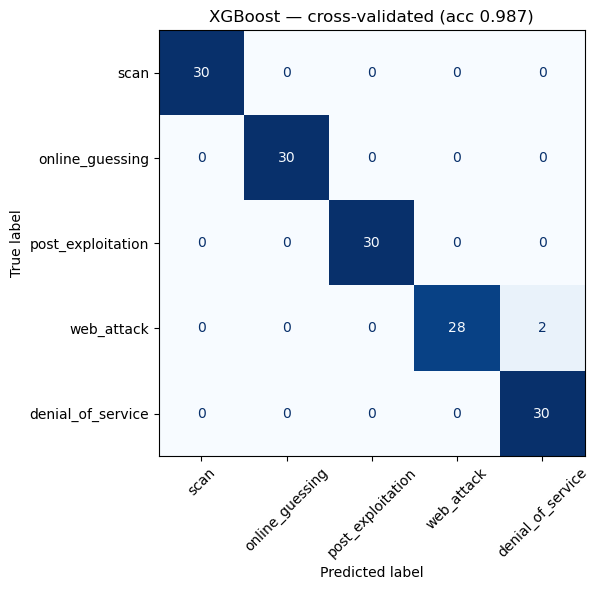

misclassified runs:
   W001: true=web_attack         -> pred=denial_of_service
   W003: true=web_attack         -> pred=denial_of_service


In [5]:
pred_xgb = full_evaluate("XGBoost", grid_xgb.best_estimator_, scaled=False)

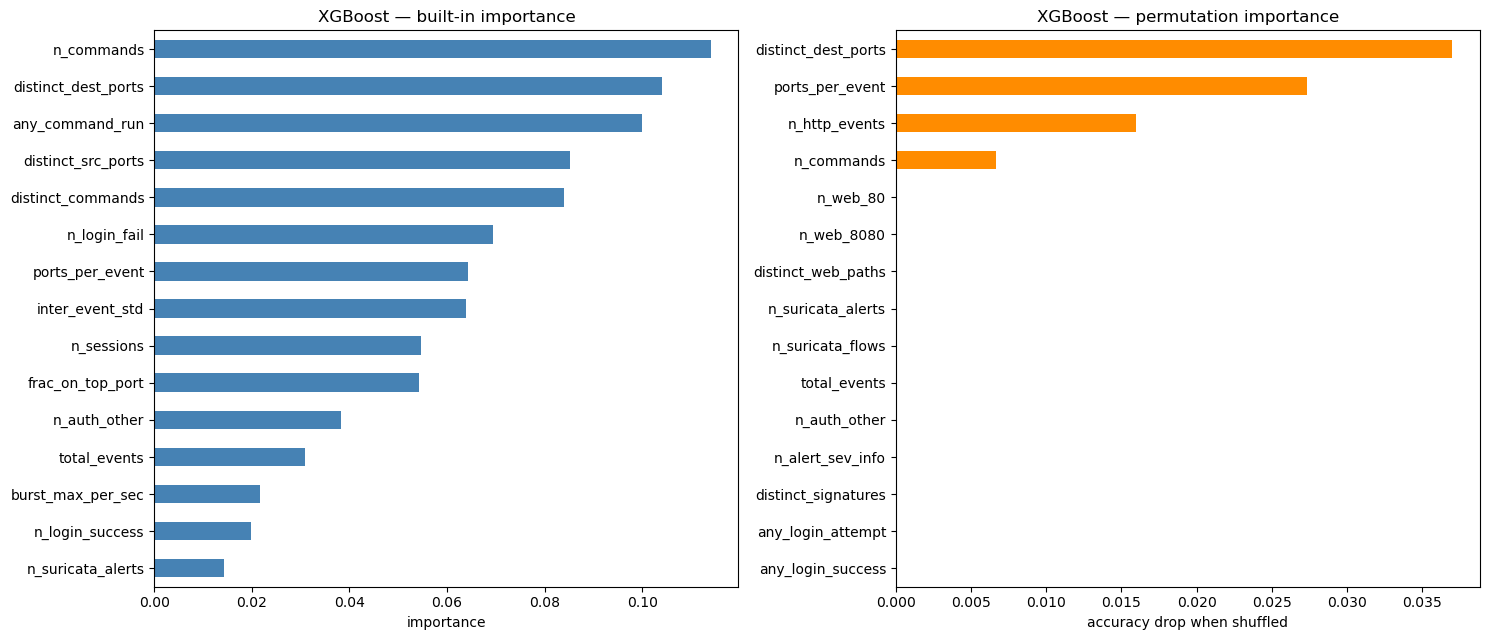

In [6]:
show_importance("XGBoost", grid_xgb.best_estimator_)   # already fitted on all 150 by the grid

## Permutation importance for scaled models
SVM, KNN, LogReg and MLP have no built-in importance, so we use permutation importance only — shuffle each feature and measure the accuracy drop. It's run on the whole Pipeline, so shuffling happens on the raw feature and the scaler is applied afterward, exactly as at prediction time.

In [7]:
def show_importance_perm(name, fitted_pipeline, n=15):
    """Permutation-only importance (for models without feature_importances_)."""
    perm = permutation_importance(fitted_pipeline, X, y_enc, n_repeats=20,
                                  random_state=RANDOM_STATE, n_jobs=-1)
    perm = pd.Series(perm.importances_mean, index=model_features).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    perm.head(n).iloc[::-1].plot.barh(ax=ax, color="darkorange")
    ax.set_title(f"{name} — permutation importance"); ax.set_xlabel("accuracy drop when shuffled")
    plt.tight_layout(); plt.show()
    print(f"top 8 by permutation importance:\n{perm.head(8).round(4)}")

## 4. SVM — widest-margin boundary with a linear kernel
An SVM finds the boundary that leaves the widest gap between classes; the RBF kernel lets that boundary curve for classes a straight line can't split. C controls how hard it fits the training points (low = smoother, high = tighter), and gamma controls how far each point's influence reaches (low = broad, high = wiggly). Scaling matters here, so StandardScaler goes inside the Pipeline and re-fits on each training fold. A few linear-kernel settings are included for contrast, both kernels were grid-searched and linear won (RBF overfit).

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_pipe = Pipeline([("scaler", StandardScaler()), ("svc", SVC(random_state=RANDOM_STATE))])

# note the "svc__" prefix: it tells GridSearch these params belong to the SVC step of the Pipeline
SVM_GRID = [
    {"svc__kernel": ["rbf"],
     "svc__C":     [0.1, 1, 10, 100, 1000],
     "svc__gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1]},
    {"svc__kernel": ["linear"],
     "svc__C":     [0.01, 0.1, 1, 10, 100]},
]
n = 5*6 + 5
print(f"grid size: {n} settings x 5 folds = {n*5} fits\n")

grid_svm = GridSearchCV(svm_pipe, SVM_GRID, cv=cv, scoring="accuracy", n_jobs=-1).fit(X, y_enc)
print("best CV accuracy:", round(grid_svm.best_score_, 4))
print("best params     :", grid_svm.best_params_)
top_combos(grid_svm, 10)

grid size: 35 settings x 5 folds = 175 fits

best CV accuracy: 0.9867
best params     : {'svc__C': 1, 'svc__kernel': 'linear'}


,mean_test_score,std_test_score,param_svc__C,param_svc__gamma,param_svc__kernel
1,0.9867,0.0163,1.0,NaN,linear
2,0.9867,0.0163,10.0,NaN,linear
3,0.9867,0.0163,100.0,NaN,linear
4,0.9800,0.0163,0.1,NaN,linear
5,0.9733,0.0249,1000.0,0.001,rbf
6,0.9667,0.0211,1.0,0.01,rbf
7,0.9667,0.0211,10.0,0.001,rbf
8,0.9667,0.0211,100.0,0.001,rbf
9,0.9600,0.0249,100.0,0.01,rbf
10,0.9600,0.0249,1000.0,0.01,rbf


=== SVM (linear) — cross-validated over all 150 runs ===
accuracy : 0.9867 ± 0.0163
macro-F1 : 0.9866 ± 0.0164
errors   : 2/150

                   precision    recall  f1-score   support

             scan      1.000     1.000     1.000        30
  online_guessing      0.968     1.000     0.984        30
post_exploitation      1.000     0.967     0.983        30
       web_attack      0.968     1.000     0.984        30
denial_of_service      1.000     0.967     0.983        30

         accuracy                          0.987       150
        macro avg      0.987     0.987     0.987       150
     weighted avg      0.987     0.987     0.987       150



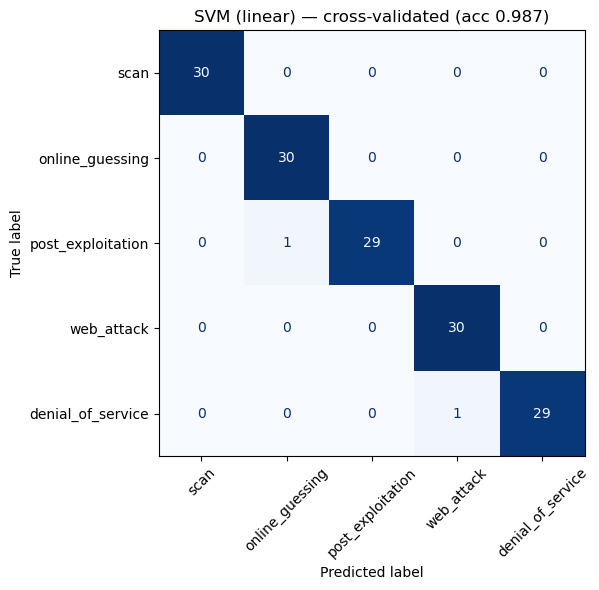

misclassified runs:
   D020: true=denial_of_service  -> pred=web_attack
   P015: true=post_exploitation  -> pred=online_guessing


In [9]:
best_kernel = grid_svm.best_params_["svc__kernel"]   # -> "linear"
svm_name = f"SVM ({best_kernel})"                     # -> "SVM (linear)"
pred_svm = full_evaluate(svm_name, grid_svm.best_estimator_, scaled=True)

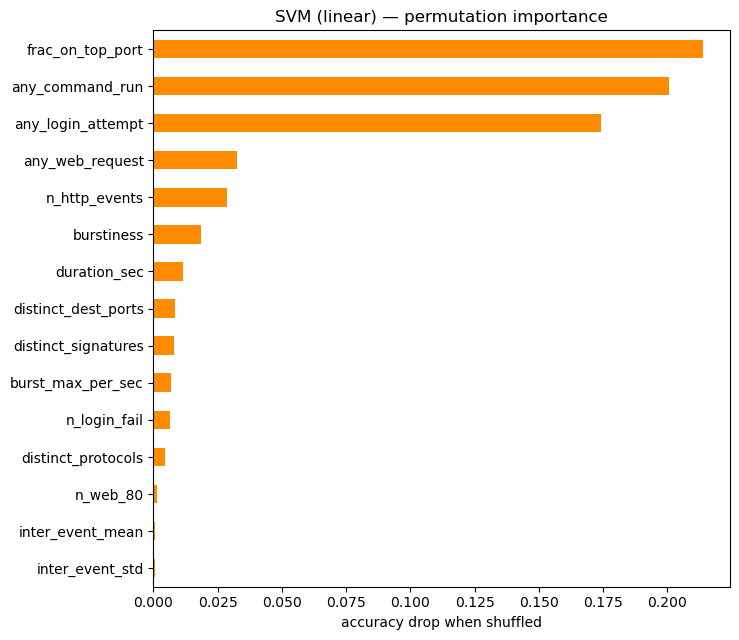

top 8 by permutation importance:
frac_on_top_port       0.2137
any_command_run        0.2007
any_login_attempt      0.1740
any_web_request        0.0327
n_http_events          0.0287
burstiness             0.0183
duration_sec           0.0113
distinct_dest_ports    0.0083
dtype: float64


In [10]:
show_importance_perm(svm_name, grid_svm.best_estimator_)

## 5. KNN — vote of the nearest neighbors
KNN doesn't build a model; it stores every run and classifies a new one by the majority vote of its k closest runs in feature space. k sets how many neighbors vote (small = noise-sensitive, large = smoother), and weights decides whether closer neighbors count more. Distance drives everything, so StandardScaler goes inside the Pipeline — otherwise large-valued features would dominate the distance. We also sweep the distance metric (Euclidean vs Manhattan).

In [11]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipe = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier())])

KNN_GRID = {
    "knn__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21],
    "knn__weights":     ["uniform", "distance"],
    "knn__p":           [1, 2],     # 1 = Manhattan distance, 2 = Euclidean distance
}
n = int(np.prod([len(v) for v in KNN_GRID.values()]))
print(f"grid size: {n} settings x 5 folds = {n*5} fits\n")

grid_knn = GridSearchCV(knn_pipe, KNN_GRID, cv=cv, scoring="accuracy", n_jobs=-1).fit(X, y_enc)
print("best CV accuracy:", round(grid_knn.best_score_, 4))
print("best params     :", grid_knn.best_params_)
top_combos(grid_knn, 10)

grid size: 32 settings x 5 folds = 160 fits

best CV accuracy: 0.9867
best params     : {'knn__n_neighbors': 3, 'knn__p': 1, 'knn__weights': 'distance'}


,mean_test_score,std_test_score,param_knn__n_neighbors,param_knn__p,param_knn__weights
1,0.9867,0.0163,3,1,distance
2,0.9800,0.0163,5,1,distance
3,0.9800,0.0163,7,1,distance
4,0.9800,0.0163,3,1,uniform
5,0.9800,0.0267,1,1,uniform
6,0.9800,0.0267,1,1,distance
7,0.9733,0.0133,5,1,uniform
8,0.9733,0.0133,7,1,uniform
9,0.9733,0.0249,3,2,distance
10,0.9733,0.0249,11,1,distance


=== KNN — cross-validated over all 150 runs ===
accuracy : 0.9867 ± 0.0163
macro-F1 : 0.9866 ± 0.0164
errors   : 2/150

                   precision    recall  f1-score   support

             scan      1.000     1.000     1.000        30
  online_guessing      1.000     1.000     1.000        30
post_exploitation      1.000     1.000     1.000        30
       web_attack      0.967     0.967     0.967        30
denial_of_service      0.967     0.967     0.967        30

         accuracy                          0.987       150
        macro avg      0.987     0.987     0.987       150
     weighted avg      0.987     0.987     0.987       150



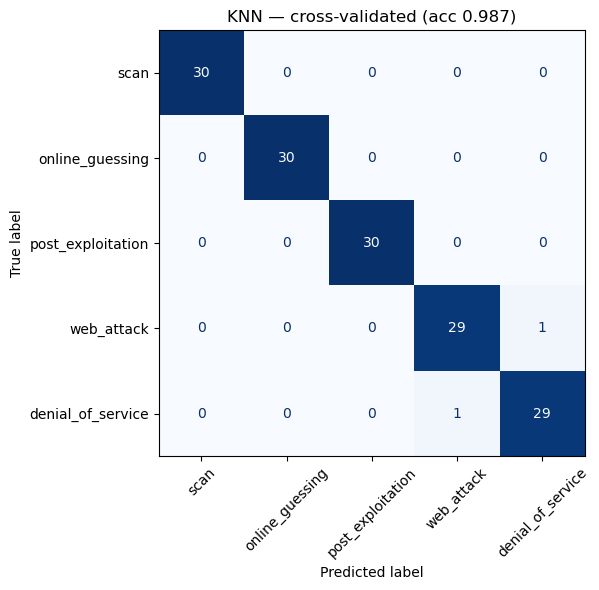

misclassified runs:
   D020: true=denial_of_service  -> pred=web_attack
   W001: true=web_attack         -> pred=denial_of_service


In [12]:
pred_knn = full_evaluate("KNN", grid_knn.best_estimator_, scaled=True)

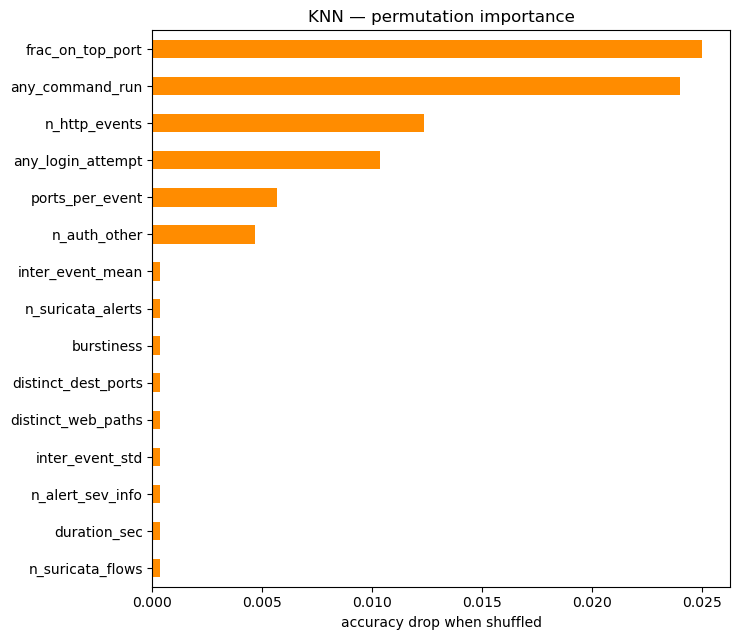

top 8 by permutation importance:
frac_on_top_port     0.0250
any_command_run      0.0240
n_http_events        0.0123
any_login_attempt    0.0103
ports_per_event      0.0057
n_auth_other         0.0047
inter_event_mean     0.0003
n_suricata_alerts    0.0003
dtype: float64


In [13]:
show_importance_perm("KNN", grid_knn.best_estimator_)   # fitted on all 150 by the grid

## 6. Logistic Regression — a linear boundary by probability
Logistic Regression also separates classes with a straight-line boundary, but instead of maximizing a margin like the SVM, it estimates each class's probability and picks the most likely. It's the natural second opinion on the SVM's "linear is enough" result. C is the regularization strength (small = simpler, more constrained; large = fits harder), and we sweep the penalty type (L2, and L1 which can zero out useless features). Scaling matters, so StandardScaler stays in the Pipeline.

In [14]:
from sklearn.linear_model import LogisticRegression

# sklearn 1.8+: 'penalty' is deprecated entirely. Don't pass it — control the penalty via l1_ratio.
# l1_ratio=0.0 -> pure L2 ; l1_ratio=1.0 -> pure L1. saga is the solver that supports the full range.
logreg_pipe = Pipeline([("scaler", StandardScaler()),
                        ("lr", LogisticRegression(solver="saga", l1_ratio=0.0,
                                                  max_iter=5000, random_state=RANDOM_STATE))])

LOGREG_GRID = {
    "lr__C":        [0.01, 0.1, 1, 10, 100],
    "lr__l1_ratio": [0.0, 1.0],     # 0.0 = L2, 1.0 = L1  (same two penalties as before)
}
n = int(np.prod([len(v) for v in LOGREG_GRID.values()]))
print(f"grid size: {n} settings x 5 folds = {n*5} fits\n")

grid_lr = GridSearchCV(logreg_pipe, LOGREG_GRID, cv=cv, scoring="accuracy", n_jobs=-1).fit(X, y_enc)
print("best CV accuracy:", round(grid_lr.best_score_, 4))
print("best params     :", grid_lr.best_params_)
top_combos(grid_lr, 10)

grid size: 10 settings x 5 folds = 50 fits

best CV accuracy: 0.9733
best params     : {'lr__C': 1, 'lr__l1_ratio': 1.0}


,mean_test_score,std_test_score,param_lr__C,param_lr__l1_ratio
1,0.9733,0.0249,1.00,1.0
2,0.9733,0.0249,10.00,0.0
3,0.9733,0.0249,100.00,0.0
4,0.9733,0.0249,100.00,1.0
5,0.9667,0.0211,10.00,1.0
6,0.9667,0.0211,1.00,0.0
7,0.9600,0.0133,0.10,0.0
8,0.9533,0.0163,0.01,0.0
9,0.9400,0.0249,0.10,1.0
10,0.2000,0.0000,0.01,1.0


=== Logistic Regression — cross-validated over all 150 runs ===
accuracy : 0.9733 ± 0.0249
macro-F1 : 0.9732 ± 0.0250
errors   : 4/150

                   precision    recall  f1-score   support

             scan      1.000     1.000     1.000        30
  online_guessing      1.000     1.000     1.000        30
post_exploitation      1.000     0.967     0.983        30
       web_attack      0.906     0.967     0.935        30
denial_of_service      0.966     0.933     0.949        30

         accuracy                          0.973       150
        macro avg      0.974     0.973     0.974       150
     weighted avg      0.974     0.973     0.974       150



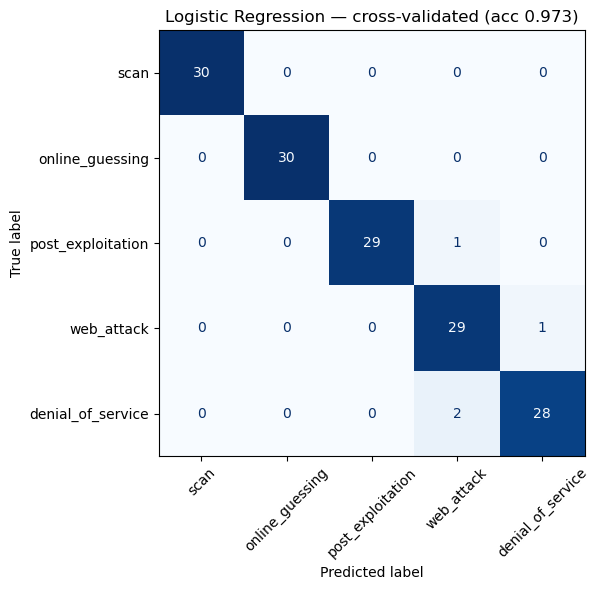

misclassified runs:
   D020: true=denial_of_service  -> pred=web_attack
   D027: true=denial_of_service  -> pred=web_attack
   P015: true=post_exploitation  -> pred=web_attack
   W002: true=web_attack         -> pred=denial_of_service


In [15]:
pred_lr = full_evaluate("Logistic Regression", grid_lr.best_estimator_, scaled=True)

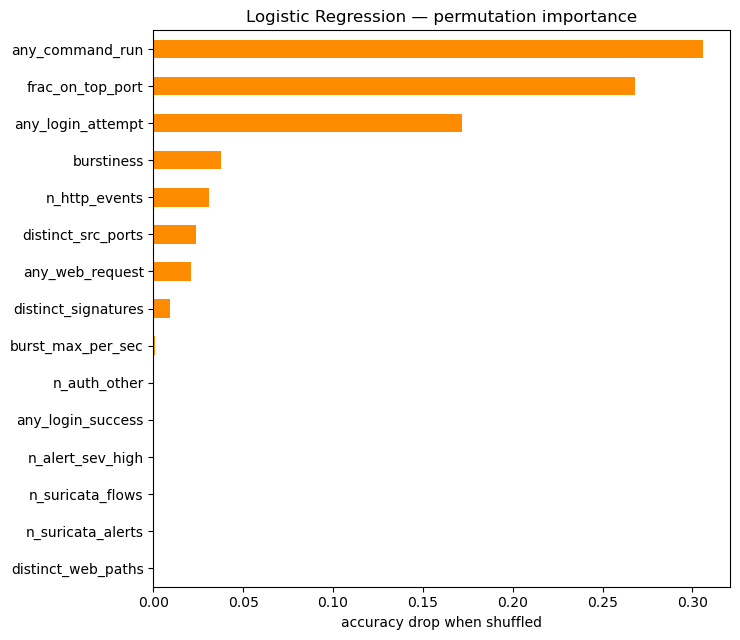

top 8 by permutation importance:
any_command_run        0.3057
frac_on_top_port       0.2683
any_login_attempt      0.1720
burstiness             0.0373
n_http_events          0.0307
distinct_src_ports     0.0237
any_web_request        0.0210
distinct_signatures    0.0090
dtype: float64


In [16]:
show_importance_perm("Logistic Regression", grid_lr.best_estimator_)

## 7. MLP — a thoroughly-tuned neural network
An MLP is a neural network: layers of neurons that can bend the decision boundary into complex non-linear shapes — the most flexible model in the lineup. We give it a genuine chance to win: a wide search over architectures (one to three layers, narrow to wide), both activations, four orders of regularization, two solvers, learning rates, and early stopping. On 150 rows this flexibility can overfit, so alpha and early stopping are the guards. Neural nets are very sensitive to feature scale, so StandardScaler stays in the Pipeline.

In [17]:
from sklearn.neural_network import MLPClassifier

mlp_pipe = Pipeline([("scaler", StandardScaler()),
                     ("mlp", MLPClassifier(max_iter=3000, random_state=RANDOM_STATE))])

# two solver families searched separately (adam uses learning_rate_init; lbfgs ignores it)
MLP_GRID = [
    {   # adam: robust default, tune the step size + early stopping
        "mlp__solver":            ["adam"],
        "mlp__hidden_layer_sizes":[(64,), (128,), (128, 64), (128, 64, 32), (100, 100)],
        "mlp__activation":        ["relu", "tanh"],
        "mlp__alpha":             [1e-4, 1e-3, 1e-2, 1e-1],
        "mlp__learning_rate_init":[1e-3, 1e-2],
        "mlp__early_stopping":    [True, False],
    },
    {   # lbfgs: often best on small tabular data (no learning rate to tune)
        "mlp__solver":            ["lbfgs"],
        "mlp__hidden_layer_sizes":[(64,), (128,), (128, 64), (128, 64, 32), (100, 100)],
        "mlp__activation":        ["relu", "tanh"],
        "mlp__alpha":             [1e-4, 1e-3, 1e-2, 1e-1],
    },
]
n = (5*2*4*2*2) + (5*2*4)
print(f"grid size: {n} settings x 5 folds = {n*5} fits\n")

grid_mlp = GridSearchCV(mlp_pipe, MLP_GRID, cv=cv, scoring="accuracy", n_jobs=-1).fit(X, y_enc)
print("best CV accuracy:", round(grid_mlp.best_score_, 4))
print("best params     :", grid_mlp.best_params_)
top_combos(grid_mlp, 10)

grid size: 200 settings x 5 folds = 1000 fits

best CV accuracy: 0.98
best params     : {'mlp__activation': 'tanh', 'mlp__alpha': 0.1, 'mlp__hidden_layer_sizes': (64,), 'mlp__solver': 'lbfgs'}


,mean_test_score,std_test_score,param_mlp__activation,param_mlp__alpha,param_mlp__early_stopping,param_mlp__hidden_layer_sizes,param_mlp__learning_rate_init,param_mlp__solver
1,0.9800,0.0267,tanh,0.1000,NaN,"(64,)",NaN,lbfgs
2,0.9800,0.0267,tanh,0.1000,NaN,"(128,)",NaN,lbfgs
3,0.9800,0.0267,tanh,0.1000,NaN,"(128, 64)",NaN,lbfgs
4,0.9733,0.0249,relu,0.0001,False,"(64,)",0.001,adam
5,0.9733,0.0249,relu,0.0001,False,"(128,)",0.001,adam
6,0.9733,0.0249,relu,0.0010,False,"(64,)",0.001,adam
7,0.9733,0.0249,relu,0.0010,False,"(128,)",0.001,adam
8,0.9733,0.0249,relu,0.0100,False,"(64,)",0.001,adam
9,0.9733,0.0249,relu,0.0100,False,"(128,)",0.001,adam
10,0.9733,0.0249,relu,0.1000,False,"(64,)",0.001,adam


=== MLP — cross-validated over all 150 runs ===
accuracy : 0.9800 ± 0.0267
macro-F1 : 0.9800 ± 0.0267
errors   : 3/150

                   precision    recall  f1-score   support

             scan      1.000     1.000     1.000        30
  online_guessing      1.000     1.000     1.000        30
post_exploitation      1.000     0.967     0.983        30
       web_attack      0.935     0.967     0.951        30
denial_of_service      0.967     0.967     0.967        30

         accuracy                          0.980       150
        macro avg      0.980     0.980     0.980       150
     weighted avg      0.980     0.980     0.980       150



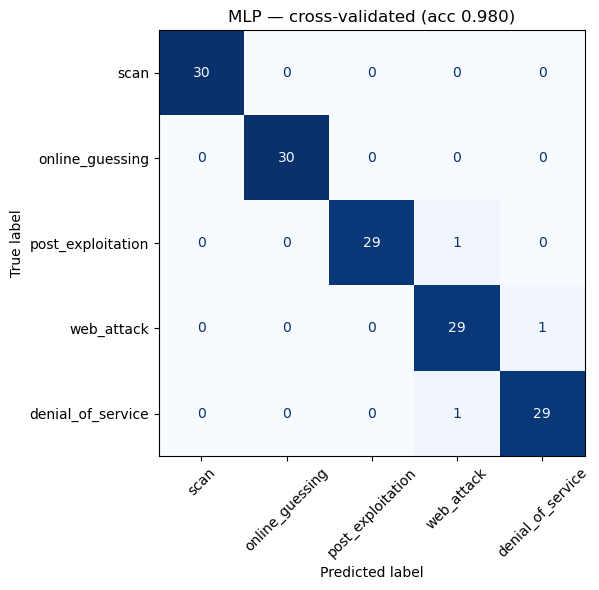

misclassified runs:
   D020: true=denial_of_service  -> pred=web_attack
   P015: true=post_exploitation  -> pred=web_attack
   W002: true=web_attack         -> pred=denial_of_service


In [18]:
pred_mlp = full_evaluate("MLP", grid_mlp.best_estimator_, scaled=True)

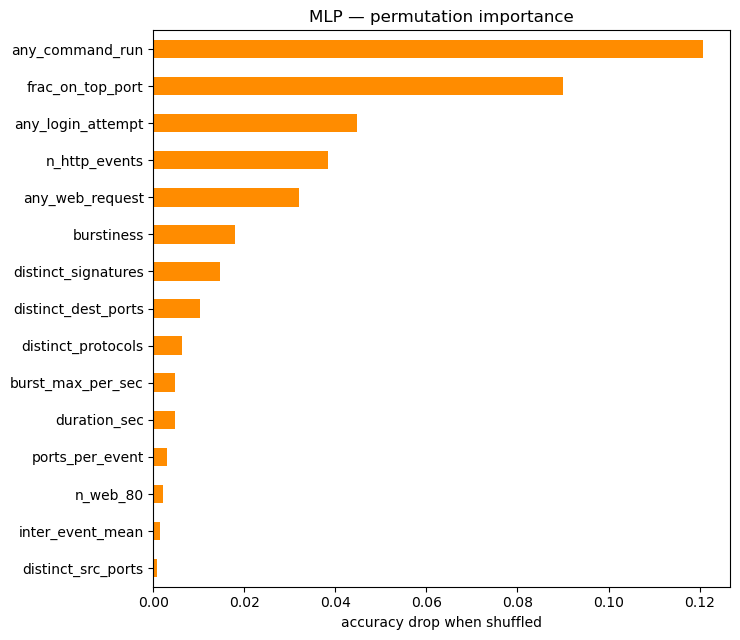

top 8 by permutation importance:
any_command_run        0.1207
frac_on_top_port       0.0900
any_login_attempt      0.0447
n_http_events          0.0383
any_web_request        0.0320
burstiness             0.0180
distinct_signatures    0.0147
distinct_dest_ports    0.0103
dtype: float64


In [19]:
show_importance_perm("MLP", grid_mlp.best_estimator_)

## 8. Final comparison — all six models
Every model scored under the identical 5-fold split, sorted by macro-F1 then accuracy. This is the headline result of the notebook: four different learning mechanisms cluster at the top, and the entire error surface across all of them reduces to one fuzzy class boundary.

,model,scaled,cv_accuracy,acc_std,cv_macro_f1,errors
1,XGBoost,False,0.9867,0.0163,0.9866,2
2,SVM (linear),True,0.9867,0.0163,0.9866,2
3,KNN,True,0.9867,0.0163,0.9866,2
4,MLP,True,0.9800,0.0267,0.9800,3
5,Random Forest,False,0.9800,0.0163,0.9799,3
6,Logistic Regression,True,0.9733,0.0249,0.9732,4


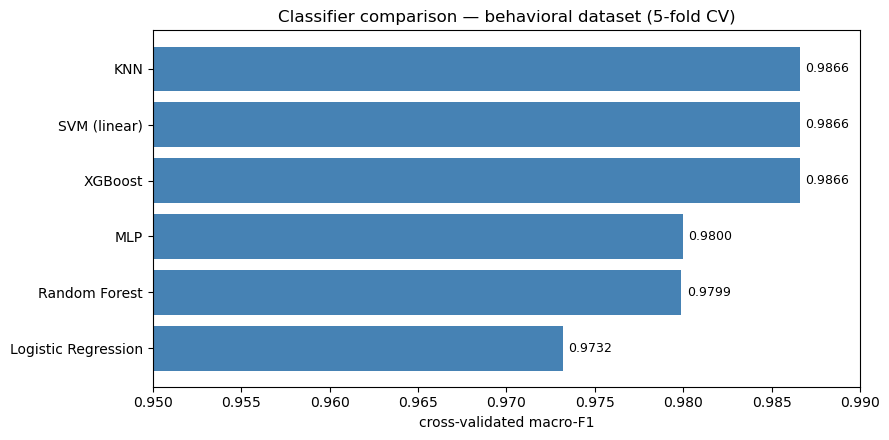

In [20]:
# de-duplicate: keep the most recent row per model (drops the repeated LogReg runs)
comparison = (pd.DataFrame(results)
              .drop_duplicates(subset="model", keep="last")
              .sort_values(["cv_macro_f1", "cv_accuracy"], ascending=False)
              .reset_index(drop=True))
comparison.index = comparison.index + 1
display(comparison)

# chart — iterate rows directly so bar position and label always match
c = comparison.sort_values("cv_macro_f1")           # smallest at bottom
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(c["model"], c["cv_macro_f1"], color="steelblue")
ax.set_xlim(0.95, 0.99)
ax.set_xlabel("cross-validated macro-F1")
ax.set_title("Classifier comparison — behavioral dataset (5-fold CV)")
for y_pos, (_, row) in enumerate(c.iterrows()):
    ax.text(row["cv_macro_f1"] + 0.0003, y_pos, f"{row['cv_macro_f1']:.4f}",
            va="center", fontsize=9)
plt.tight_layout(); plt.show()

## 9. Save the deployed model — XGBoost
The comparison chose XGBoost (tied best at 0.9867, 2 errors). Refit the winning configuration on all 150 rows and save it, along with everything needed to use it elsewhere: the exact 32-feature list (so inference builds identical input), the integer→class-name map (XGBoost predicts 0–4), the full model comparison, and metadata recording the versions the model was built with. The last lines reload the saved model and predict once to prove it's usable.

In [21]:
import datetime
from xgboost import XGBClassifier

# refit the winning XGBoost configuration on ALL 150 rows (self-contained + explicit)
xgb_best = grid_xgb.best_params_
deployed = XGBClassifier(**xgb_best, eval_metric="mlogloss", tree_method="hist",
                         random_state=RANDOM_STATE, n_jobs=1).fit(X, y_enc)

Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)

# 1) the model itself (native XGBoost format + a joblib pickle; both load fine, keep both)
deployed.save_model(str(Path(MODELS_DIR) / "deployed_model.json"))   # portable XGBoost format
joblib.dump(deployed, Path(MODELS_DIR) / "deployed_model.pkl")       # convenient for Python inference

# 2) the exact 32 features IN ORDER — inference must build X with these columns, same order
with open(Path(MODELS_DIR) / "feature_columns.json", "w") as f:
    json.dump(model_features, f, indent=2)

# 3) integer -> class name map (XGBoost predicts 0-4; this turns that back into names)
with open(Path(MODELS_DIR) / "class_labels.json", "w") as f:
    json.dump(CLASS_ORDER, f, indent=2)

# 4) the full six-model comparison, for the report
comparison.to_csv(Path(MODELS_DIR) / "model_comparison.csv", index=False)

# 5) metadata: what won, its score, and the exact versions the pickle needs
meta = {
    "deployed_model": "XGBoost",
    "params": xgb_best,
    "cv_accuracy": float(comparison.iloc[0]["cv_accuracy"]),
    "cv_macro_f1": float(comparison.iloc[0]["cv_macro_f1"]),
    "errors": int(comparison.iloc[0]["errors"]),
    "n_features": len(model_features),
    "n_train_rows": int(len(y_enc)),
    "class_order": CLASS_ORDER,
    "sklearn_version": sklearn.__version__,
    "xgboost_version": __import__("xgboost").__version__,
    "numpy_version": np.__version__,
    "saved_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(timespec="seconds"),
}
with open(Path(MODELS_DIR) / "deployed_model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("saved to", MODELS_DIR)
for name in ["deployed_model.json", "deployed_model.pkl", "feature_columns.json",
             "class_labels.json", "model_comparison.csv", "deployed_model_meta.json"]:
    p = Path(MODELS_DIR) / name
    print(f"   {name:28} ({p.stat().st_size:,} bytes)")

# reload check — confirm the saved model is usable and maps back to a class name
reloaded = joblib.load(Path(MODELS_DIR) / "deployed_model.pkl")
pred0 = reloaded.predict(X[:1])[0]
print("\nreload check — first run predicted:", CLASS_ORDER[pred0], "| true:", CLASS_ORDER[y_enc[0]])

saved to C:\tpot-project\06-models
   deployed_model.json          (1,127,113 bytes)
   deployed_model.pkl           (1,553,295 bytes)
   feature_columns.json         (698 bytes)
   class_labels.json            (101 bytes)
   model_comparison.csv         (286 bytes)
   deployed_model_meta.json     (593 bytes)

reload check — first run predicted: online_guessing | true: online_guessing
